# SCF Abstraction: Initialisation of SCF Objects

Following the logic of the SCF kernel, the following step after allocation is inicialisation. This basically consists in actually filling the allocated memory with the correct needed constants.


In [1]:
import numpy as np
import scipy

from py_mods.src.SCF_4c.types_4c import (
    CS_4c_KU_SCF_Context,
    CS_4c_KU_SCF_Constants,
    CS_4c_KU_SCF_State,
    allocate_CS_4c_KU_SCF_extended_context,
    allocate_CS_4c_KU_SCF_state,
)

from py_mods.src.external.DIRAC_ME import (
    build_S_V_W_T_from_h5,
    get_nuc_charge,
    full_eri_from_h5,
    build_uncontracted_basis_from_h5,
)

from py_mods.src.SCF_4c.scf_4c_kernels import (
    occupation_4c,
    eri_classified,
)


from py_mods.src.SCF.linalg import transformation_matrix
from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.CSRHF import guess_density_RHF

from py_mods.src.SCF.utils import initialize_conv_acc

from py_mods.src.SCF_4c.utils import validate_4c_determinant

from py_mods.src.SCF_4c.scf_4c_kernels import scale_4c_integrals

import matplotlib.pyplot as plt

We start by adapting the initialization routine:

In [2]:
def initialize_CS_4c_KU_SCF_extended_context(
    ctx: CS_4c_KU_SCF_Context, rhf_ext_ctx: CS_4c_KU_SCF_Constants
) -> None:
    """
    Setup extended context with transformation matrix, validated determinant and scaled integrals.  Also set up convergence acceleration parameters.

    Parameters
    ----------
    ctx : CS_4c_KU_SCF_Context
        Original context with integrals and parameters.
    rhf_ext_ctx : CSRHFConstants
        Initialized extended context to compute.

    Returns
    -------
    None
    """

    rhf_ext_ctx.dim = len(ctx.S)
    rhf_ext_ctx.X = transformation_matrix(ctx.S.astype(np.complex128)).astype(
        np.complex128
    )

    # validate occupation
    rhf_ext_ctx.full_det, _ = validate_4c_determinant(
        ctx.nS, ctx.nL, ctx.n_electrons, ctx.occ
    )

    # rescaling the integrals
    T_scaled, V_scaled, W_scaled, rhf_ext_ctx.eri_scaled = scale_4c_integrals(
        ctx.T, ctx.V, ctx.W, ctx.eri_classess, ctx.theta
    )

    rhf_ext_ctx.H_core = T_scaled + V_scaled + W_scaled
    rhf_ext_ctx.core_mask = np.abs(rhf_ext_ctx.H_core) > 1e-10

    # eigensolver enforced
    if ctx.theta != 0:
        rhf_ext_ctx._eigensolver = "eig"
    else:
        rhf_ext_ctx._eigensolver = ctx._eigensolver

    # Convergence acceleration setup
    rhf_ext_ctx.acc_iteration_start, rhf_ext_ctx.acc_requested = initialize_conv_acc(
        ctx.acc_hist_size, ctx.conv_type, ctx.acc_iteration_start
    )
    
    return

And now we are going to generate some tests:



In [3]:
h5_filename = "data/He_checkpoint.h5"

S, V, W, T = build_S_V_W_T_from_h5(h5_filename)
H_nuc = V + W + T
nuc_charge = get_nuc_charge(h5_filename)

_, nL, nS = build_uncontracted_basis_from_h5(h5_filename)
eri = full_eri_from_h5(h5_filename)
eri = eri_classified(eri, nL)

occ_det = occupation_4c(nS, nL, 2)

## 1. Scaling testing

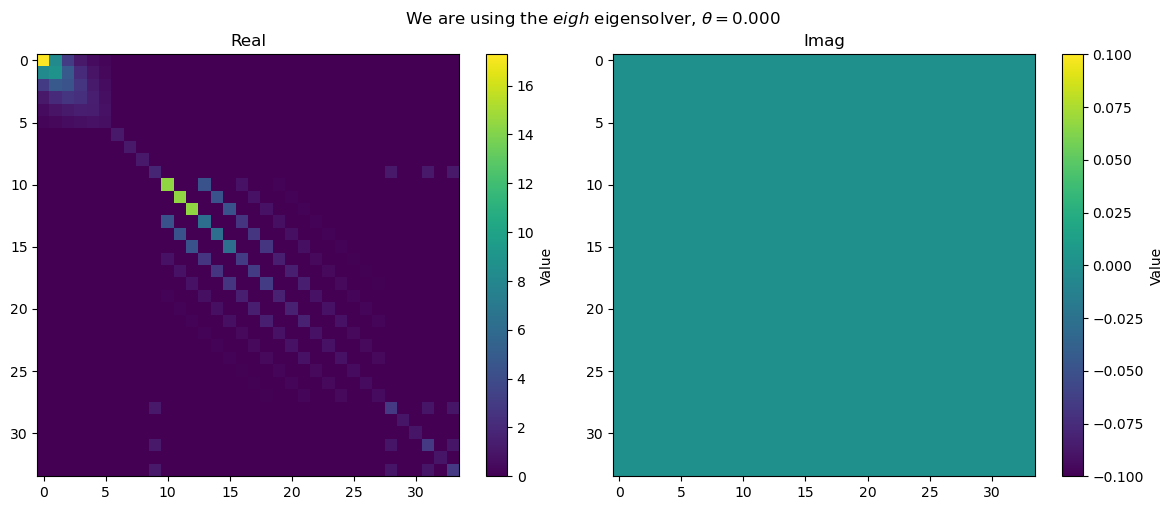

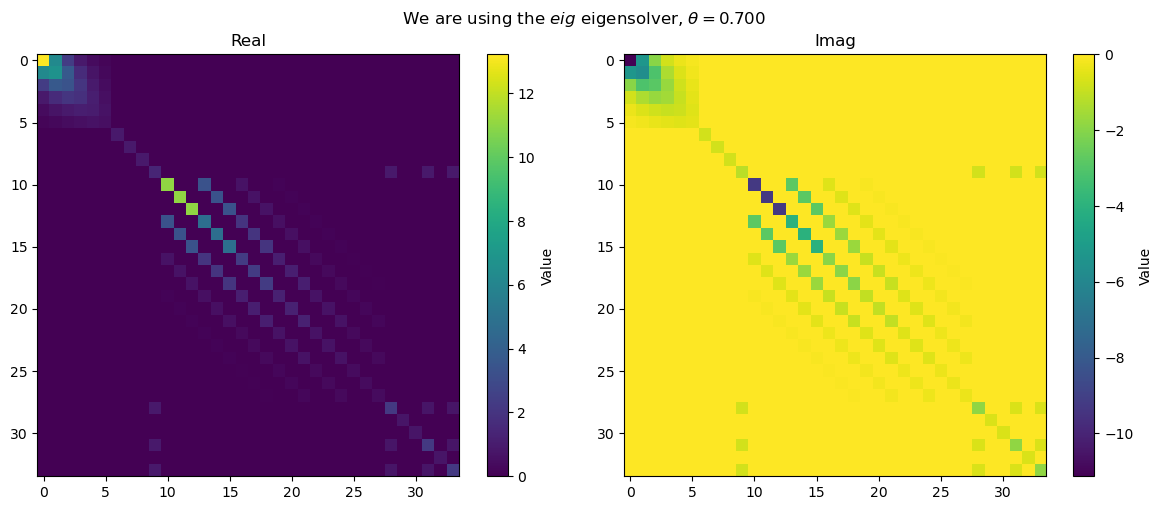

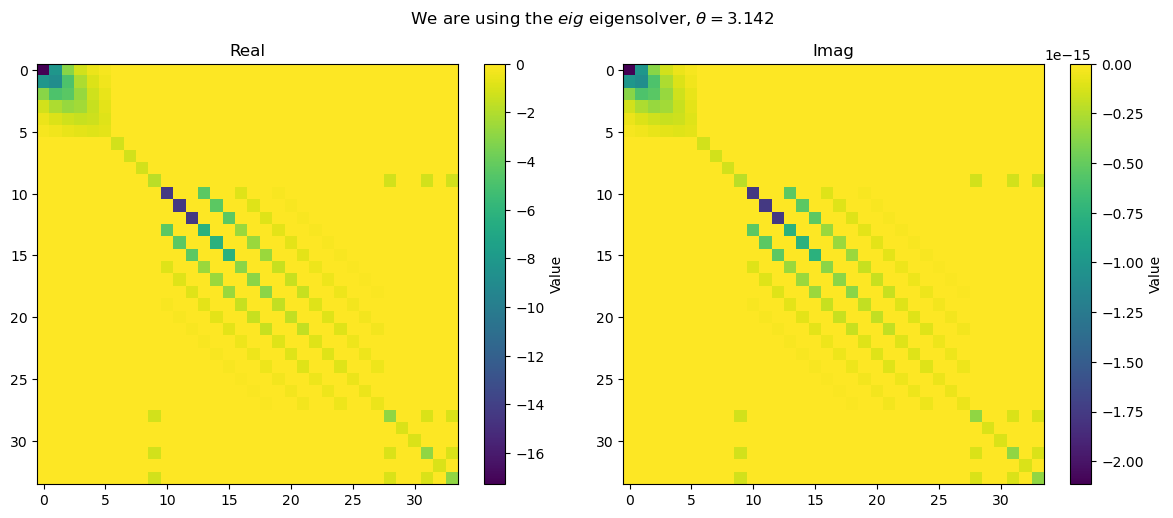

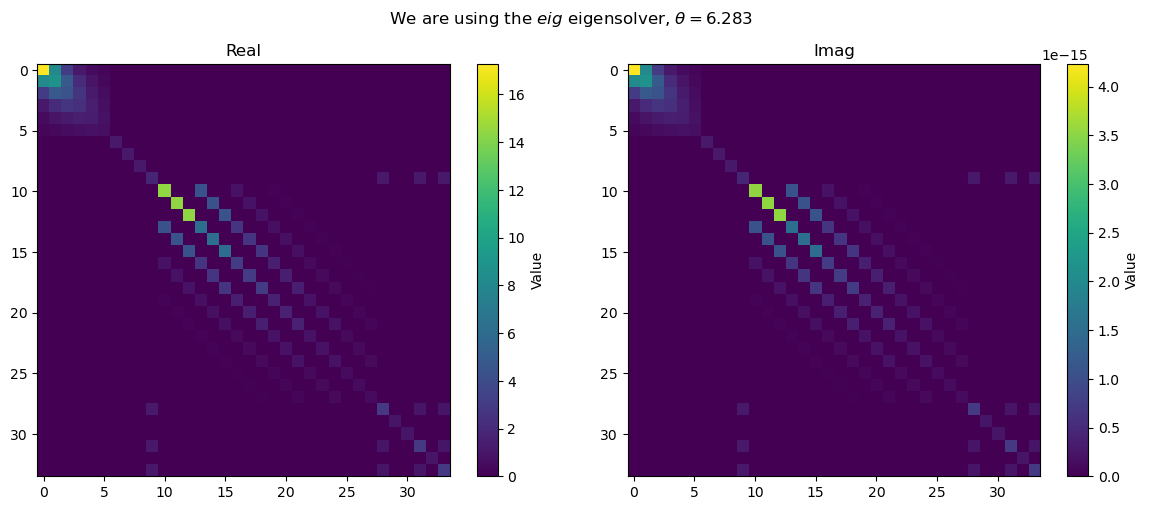

In [4]:
for theta in (0, 0.7, np.pi, 2*np.pi):
    test_ctx = CS_4c_KU_SCF_Context(nL, nS, S, T, V, W, eri, 2, theta=theta)
    test_ext_ctx = allocate_CS_4c_KU_SCF_extended_context(test_ctx)
    # print(test_ctx.theta)
    initialize_CS_4c_KU_SCF_extended_context(test_ctx, test_ext_ctx)
    plot_map(test_ext_ctx.eri_scaled[:,:,0,0], title=f"We are using the ${test_ext_ctx._eigensolver}$ eigensolver, $\\theta = {test_ctx.theta:.3f}$")

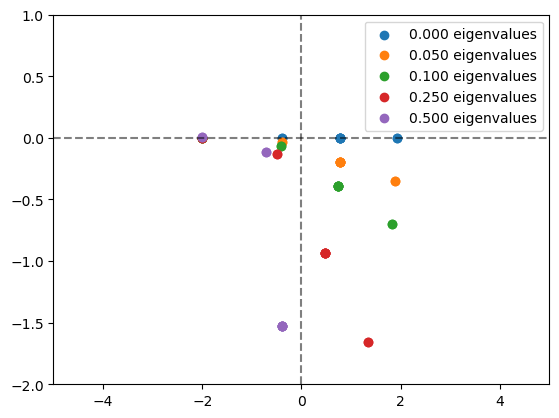

In [5]:
for theta in (0, 0.05, 0.1, 0.25, 0.5):
    test_ctx = CS_4c_KU_SCF_Context(nL, nS, S, T, V, W, eri, 2, theta=theta)
    test_ext_ctx = allocate_CS_4c_KU_SCF_extended_context(test_ctx)
    # print(test_ctx.theta)
    initialize_CS_4c_KU_SCF_extended_context(test_ctx, test_ext_ctx)

    F_0 = test_ext_ctx.H_core

    e, w = scipy.linalg.eig(F_0, test_ctx.S)

    idx = np.argsort(e.real)
    e = e[idx]
    w = w[:, idx]

    # print(e[-2 * nL :])

    plt.scatter(e.real[-2 * nL :], e.imag[-2 * nL :], label=f"{theta:.3f} eigenvalues")

plt.legend()
plt.xlim(-5, 5)
plt.ylim(-2, 1)
plt.vlines(0, -2, 1, colors="k", linestyles="dashed", alpha=0.5)
plt.hlines(0, -5, 5, colors="k", linestyles="dashed", alpha=0.5)
plt.show()

## Occupation testing

In [6]:
occ1 = np.zeros(2 * nL)
occ1[:2] = 1
occ2 = np.array([1, 1, 0], dtype=np.int8)
occ3 = np.zeros(2 * (nL + nS))
occ3[2 * nS : 2 * nS + 2] = 1
occ4 = np.zeros(2 * (nL + nS))
occ4[2 * nS + 2] = 1
occ4[2 * nS + 7] = 1

print(occ1)
print(occ2)
print(occ3)
print(occ4)

[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1 1 0]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
for occ in (occ1, occ2, occ3, occ4):
    test_ctx = CS_4c_KU_SCF_Context(nL, nS, S, T, V, W, eri, 2, theta=0, occ=occ)
    test_ext_ctx = allocate_CS_4c_KU_SCF_extended_context(test_ctx)
    # print(test_ctx.theta)
    initialize_CS_4c_KU_SCF_extended_context(test_ctx, test_ext_ctx)
    print(test_ext_ctx.full_det)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


Where it behaves (seemingly) as it should. 

---

# 2. State variable
It is now time to adapt the state variable initializer

In [8]:
def initialize_CS_4c_KU_SCF_state_variable(
    ext_ctx: CS_4c_KU_SCF_Constants, state: CS_4c_KU_SCF_State
) -> None:
    state.use_conv_acc = False
    state.converged = False
    state.F_guess = []
    state.residuals = []
    state.F_next = np.zeros_like(ext_ctx.H_core)
    state.e_orb = np.zeros(ext_ctx.dim, dtype=np.complex128)
    state.C_prime = np.zeros(
        (ext_ctx.dim, ext_ctx.dim), dtype=np.complex128
    )
    state.C_munu = np.zeros_like(state.C_prime, dtype=np.complex128)
    state.error = np.complex128(1e10)

    return

Ans we test it out:

In [9]:
test_state = allocate_CS_4c_KU_SCF_state(test_ctx)
initialize_CS_4c_KU_SCF_state_variable(test_ext_ctx, test_state)
test_state.__dict__.keys()

dict_keys(['iteration', 'P', 'E_prev', 'use_conv_acc', 'F_guess', 'residuals', 'F_next', 'error', 'converged', 'C_munu', 'C_prime', 'e_orb', 'e_electronic_orb', 'F', 'r', 'E_SCF', 'E_diff', 'P_old'])

# 3. Density initialization
And finally we adapt the density initialization

In [10]:
def initialize_CS_4c_KU_SCF_P_and_E(
    ctx: CS_4c_KU_SCF_Context,
    rhf_state: CS_4c_KU_SCF_State,
) -> None:

    if ctx.theta != 0.0:
        # TODO: this cannot be filled until the routine has been adapted
        pass
        P = guess_density_RHF(ctx.p_guess, len(ctx.S), ctx.initial_orbitals)
        E_prev = np.complex128(0.0)
        # P, unscaled_E_RHF = compute_rhf_unscaled_density(ctx, ctx.verbose)
        # E_prev = np.complex128(unscaled_E_RHF)

    else:
        P = guess_density_RHF(ctx.p_guess, len(ctx.S), ctx.initial_orbitals)
        E_prev = np.complex128(0.0)

    rhf_state.P = P
    rhf_state.E_prev = E_prev

    return

In [11]:
test_ctx = CS_4c_KU_SCF_Context(nL, nS, S, T, V, W, eri, 2, theta=0, occ=occ1, p_guess="ones")
test_const = allocate_CS_4c_KU_SCF_extended_context(test_ctx)
test_state = allocate_CS_4c_KU_SCF_state(test_ctx)

initialize_CS_4c_KU_SCF_extended_context(test_ctx, test_const)
initialize_CS_4c_KU_SCF_P_and_E(test_ctx, test_state)
initialize_CS_4c_KU_SCF_state_variable(test_const, test_state)

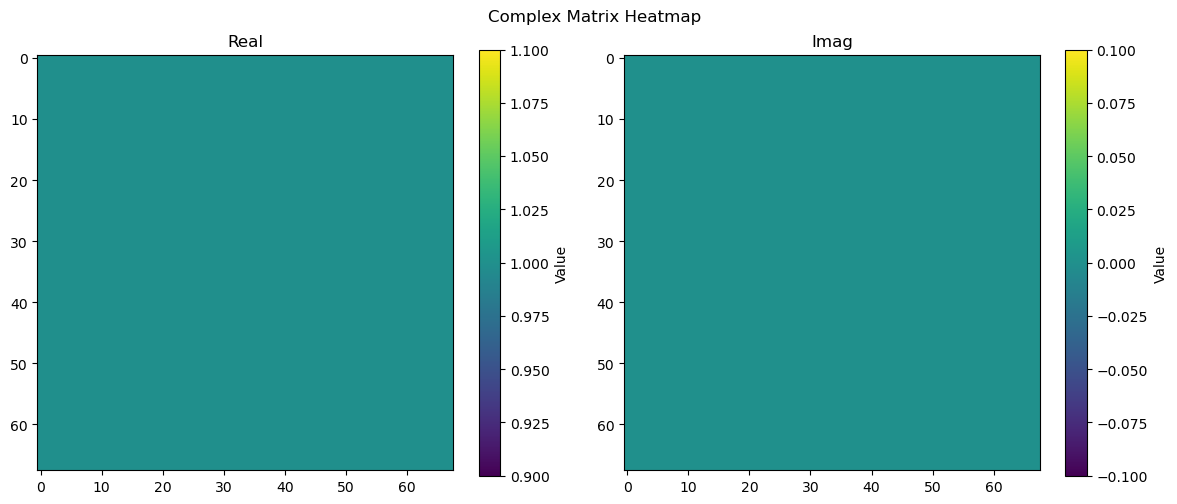

In [12]:
plot_map(test_state.P)